# Lecture 6 - Basic Statistics I

## Today's Key Takeaways

- Understanding distributions
 - Normal distribution
- Testing for **difference** between two distributions
- Type I error


## Basic Statistics with `scipy` and `statsmodels`

The `scipy` library expands the `numpy` suite of mathematical functions. Like `numpy`, these are broken up into sublibraries. We'll use the `stats` sublibary to run a t-test on our highly variable genes, and use ANOVA on one of those genes.

Note that we used a new method of importing. Some libraries, like scipy, have multiple sub-libraries. You can import just the sub-library using the `from` command. This saves memory and time.

We are mostly going to use the stats sublibrary, but we imported all of scipy so we can look over the help file and functions.

For more info about basic statistical testing, go [here](https://machinelearningmastery.com/statistical-hypothesis-tests-in-python-cheat-sheet/) and [here](http://scipy-lectures.org/packages/statistics/index.html).

In [2]:
# Import required libraries
import numpy as np
import pandas as pd
import scipy
from scipy import stats
import statsmodels.stats.multitest as smm
import statsmodels.stats.nonparametric as nonparam
import matplotlib.pyplot as plt
from statsmodels.formula.api import ols
import seaborn as sns

In [3]:
# Setting some pandas preferences
pd.set_option('display.precision', 2)
pd.set_option('display.max_columns',10)

## Start by initializing some data

In [4]:
# importing the melanoma dataset
melanoma_log2 = pd.read_excel('~/LECTURE_MATERIALS/DataFiles/melanoma_zerosRemoved_log2transformed_2026.xlsx',index_col = 0)
melanoma_log2.head()

,Sample_geo_accession,Stage,cell type,sample_number,cell_line,...,ZYX,ZZEF1,ZZZ3,BP-21201H5.1,BP-2189O9.2
Sample Title,,,,,,,,,,,
FM_1,GSM2344965,primary melanocytes,normal melanocytes,1,FM,...,11.66,11.83,10.55,3.17,1.00
FM_2,GSM2344966,primary melanocytes,normal melanocytes,2,FM,...,11.63,11.54,11.06,2.81,2.00
FM_3,GSM2344967,primary melanocytes,normal melanocytes,3,FM,...,12.31,11.44,10.81,2.32,1.58
SK_MEL_28_1,GSM2344968,metastatic,melanoma cell line,4,SK_MEL_28,...,11.86,10.94,11.64,0.00,6.04
SK_MEL_28_2,GSM2344969,metastatic,melanoma cell line,5,SK_MEL_28,...,11.97,11.03,11.74,1.00,6.41


We're also going to extract out data frames specific to the different stages, and specific to the cell lines.

In [4]:
# Extracting out only the gene expression dat from the normal samples and the metastatic samples
normalExp = melanoma_log2.loc[melanoma_log2.Stage == 'primary melanocytes','A1BG':]
metastaticExp = melanoma_log2.loc[melanoma_log2.Stage == 'metastatic','A1BG':]
print(normalExp)
print(metastaticExp)

              A1BG    A2M   AAAS   AACS  AADAT  ...    ZYX  ZZEF1   ZZZ3  \
Sample Title                                    ...                        
FM_1          8.64  14.51  10.54  10.79   8.18  ...  11.66  11.83  10.55   
FM_2          8.32  15.54  10.42  11.01   8.65  ...  11.63  11.54  11.06   
FM_3          8.94  14.32  10.63  11.42   8.83  ...  12.31  11.44  10.81   

              BP-21201H5.1  BP-2189O9.2  
Sample Title                             
FM_1                  3.17         1.00  
FM_2                  2.81         2.00  
FM_3                  2.32         1.58  

[3 rows x 15358 columns]
              A1BG    A2M   AAAS   AACS  AADAT  ...    ZYX  ZZEF1   ZZZ3  \
Sample Title                                    ...                        
SK_MEL_28_1   8.37  11.37  10.76  10.70   8.56  ...  11.86  10.94  11.64   
SK_MEL_28_2   8.50  11.40  10.91  10.74   8.84  ...  11.97  11.03  11.74   
SK_MEL_28_3   8.61  11.48  10.93  10.51   8.50  ...  11.94  11.02  11.59   
SK_

In [5]:
# Extracting out only the gene expression data from each of the cell line samples
FMexp = melanoma_log2.loc[melanoma_log2.cell_line == 'FM','A1BG':]
SK28exp = melanoma_log2.loc[melanoma_log2.cell_line == 'SK_MEL_28','A1BG':]
SK147exp = melanoma_log2.loc[melanoma_log2.cell_line == 'SK_MEL_147','A1BG':]
UACCexp = melanoma_log2.loc[melanoma_log2.cell_line == 'UACC_62','A1BG':]

In [6]:
# Reminder from last time:
# calculates the overall variance df.var() and sorts it in descending order
overall_variance = melanoma_log2.loc[:,'A1BG':].var()
overall_variance.sort_values(inplace = True, ascending= False)
print(overall_variance.head())

# extract gene names for top 10 most variably expressed genes
topvarGens10 = overall_variance.index[:10]
print(topvarGens10)


PMEL     47.63
TYRP1    38.53
AEBP1    36.08
GLUL     33.23
TYR      32.25
dtype: float64
Index(['PMEL', 'TYRP1', 'AEBP1', 'GLUL', 'TYR', 'EEF1A2', 'CDC42EP1', 'A2M',
       'SOD3', 'TGFBI'],
      dtype='object')


## Assessing the distribution of the data
You can assess the percentiles with the `np.percentile()` function or the `.quantile()` method .

In [7]:
np.percentile(metastaticExp.A1BG,[10,90])

array([7.92611329, 8.8008864 ])

In [8]:
metastaticExp.A1BG.quantile([0.1,0.9])

0.1    7.93
0.9    8.80
Name: A1BG, dtype: float64

Text(0, 0.5, 'Number of genes')

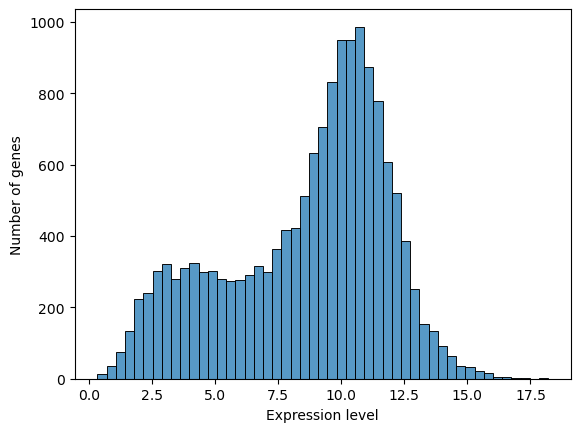

In [9]:
# Code for plotting a histogram
g = sns.histplot(metastaticExp.mean()) #, bins=[-0.5, 0.5, 1.5, 2.5, 3.5])
plt.xlabel('Expression level')
plt.ylabel('Number of genes')

## Hypothesis testing: comparing groups of samples

How can we be certain that two random variables are different (e.g. primary melanocytes vs. metastatic)? A two-sample statistical test can be used to compare to independent samples.

Statistical jargon:
 - Statistical testing is also called hypothesis testing
 - Generally we are testing the "null hypothesis (H0)" that two variables are from the same distribution
 - The "alternative hypothesis (H1)" is that the two variables are from different distributions, or distributions with a different mean
 - We "reject" the null hypothesis if there is sufficient evidence


In [10]:
# Start by printing out the expression values of the top variable genes
print(normalExp.loc[:,topvarGens10])
print(metastaticExp.loc[:,topvarGens10])

               PMEL  TYRP1  AEBP1   GLUL    TYR  EEF1A2  CDC42EP1    A2M  \
Sample Title                                                               
FM_1          18.62  19.46  13.93  12.95  15.88     1.0     11.44  14.51   
FM_2          18.64  19.61  13.63  12.99  16.48     1.0     10.56  15.54   
FM_3          18.66  19.34  14.61  13.02  16.53     0.0     10.88  14.32   

              SOD3  TGFBI  
Sample Title               
FM_1          4.46   3.70  
FM_2          6.07   6.38  
FM_3          6.17   6.27  
               PMEL  TYRP1  AEBP1   GLUL    TYR  EEF1A2  CDC42EP1    A2M  \
Sample Title                                                               
SK_MEL_28_1   17.40  10.54   0.00   2.81  12.88    6.17      1.00  11.37   
SK_MEL_28_2   17.60  10.10   1.58   1.00  13.10    6.23      1.00  11.40   
SK_MEL_28_3   17.77  10.18   2.32   2.00  13.02    7.04      1.00  11.48   
SK_MEL_147_1   3.70   3.91   1.00  10.49   2.00   14.11     12.47   2.00   
SK_MEL_147_2   4.17   3

### Comparing two samples, parametric: Student's t-test

A two-sample t-test can be used to compare two samples (sets of observations from a random variable). The null hypothesis is that the two sets of observations were drawn from the same normally distributed random variable (i.e., equal mean and variance).

The function `stats.ttest_ind` tests whether the means of two independent samples are significantly different and estimates a *t-statistic* and *p-value* from two vectors of observations

Assumptions:

 - Observations in each sample are independent and identically distributed (iid).
 - Observations in each sample are normally distributed.
 - Observations in each sample have the same variance.



Let's compare the most variably expressed gene, PMEL.

In [11]:
# Show what PMEL's expression looks like.
melanoma_log2.loc[:,['Stage','PMEL']]

,Stage,PMEL
Sample Title,,
FM_1,primary melanocytes,18.62
FM_2,primary melanocytes,18.64
FM_3,primary melanocytes,18.66
SK_MEL_28_1,metastatic,17.40
SK_MEL_28_2,metastatic,17.60
SK_MEL_28_3,metastatic,17.77
SK_MEL_147_1,metastatic,3.70
SK_MEL_147_2,metastatic,4.17
SK_MEL_147_3,metastatic,4.95


In [19]:
# test the significance of the difference in means with a 2-sample t-test (for independent samples)
stat, p = stats.ttest_ind(normalExp.PMEL, metastaticExp.PMEL)
print('the t-statistic is:',stat) # the t-statistic
print('the t-test p-value is:',p) # the p-value

the t-statistic is: 2.4979143130848978
the t-test p-value is: 0.031559414275392335


**Note:** for comparisons with unequal variances, you can specify `equal_var = False` as an argument in the `ttest_ind()` function.

In [26]:
# test the significance of the difference in means with a Welch's t-test (to account for unequal standard deviations)
stat, p = stats.ttest_ind(normalExp.PMEL, metastaticExp.PMEL,equal_var = False)
print('the t-test p-value is:',p) # the p-value

the t-test p-value is: 0.002087526843229534


### Outliers and rank tests

Outliers are meaurements from a random variable that lay substantially outside the distribution. They can happen because of some kind of technical artifact or error in our experiments, but it can be difficult to identify the problem. Generally, if we can't identify the problem, the data shouldn't be excluded from the **primary analysis**, but could be excluded form **sensitivity analyses**.

The histograms below demonstrate why outliers can be a problem. They will tend to bias our estimate of the mean, and can lead us to incorrectly conclude there are significant differences between two samples (i.e., inflate type-I error)

In the example below, we have two samples from the same normal distribution (mean = 0, standard deviation = 1), but in one case (the right plot with blue bars) we've created 3 outliers by adding 6 to three of the observations.

distribution mean: -0.631  distribution std: 1.054
outlier distribution mean: 2.013  outlier distribution std: 3.339
T-test p-value: 0.036


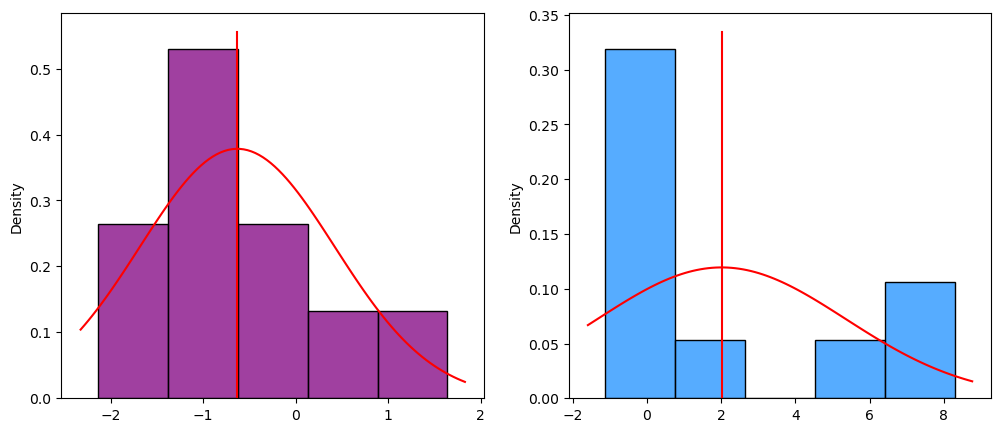

In [28]:
figh, (left_ax, right_ax) = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

np.random.seed(2)
n_samples = 10

### Left plot: no outliers
data_a = np.random.normal(loc=0, scale=1, size=(n_samples,))
plt.sca(left_ax) # sets the current plotting axes to the left_ax
sns.histplot(data_a, stat='density', color='purple')

### Estimate the mean and standard deviation of a distribution
mean_est = np.mean(data_a)
std_est = np.std(data_a)
print(f'distribution mean: {mean_est:1.3f}',f' distribution std: {std_est:1.3f}',)

### Overlay the estimated distribution
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mean_est, std_est)
plt.plot(x, p, 'red')
ymin, ymax = plt.ylim()
plt.plot([mean_est, mean_est], [0, ymax], 'red')

### Right plot: three outliers
data_b = np.random.normal(loc=0, scale=1, size=(n_samples,))
data_b[:3] = np.abs(data_b[:3]) + 6 #adding 6 to create outliers
plt.sca(right_ax)
sns.histplot(data_b, stat='density', color='dodgerblue')

### Estimate the mean and standard deviation of a distribution
mean_est = np.mean(data_b)
std_est = np.std(data_b)
print(f'outlier distribution mean: {mean_est:1.3f}',f' outlier distribution std: {std_est:1.3f}',)

### Overlay the estimated distribution
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mean_est, std_est)
plt.plot(x, p, 'red')
ymin, ymax = plt.ylim()
plt.plot([mean_est, mean_est], [0, ymax], 'red')

### Run a t-test comparing the two samples
tstat, p = stats.ttest_ind(data_a, data_b)
print(f'T-test p-value: {p:1.3f}')

#### Rank-based tests can be used to make inferences that are robust to outliers

A rank-based test means that all the values of your observations are first converted to their ranking from lowest to highest values across the two distributions. Then there are statistical tests that have been designed to operate on ordinal ranking data instead of normally distributed data. Example rank-based tests include:

 - Mann-Whitney U test (aka Wilcoxon rank sum) is a rank-based version of the t-test: `stats.ranksums` and `stats.mannwhitneyu` (effectively the same test)
 - Wilcoxon signed-rank test is a rank-based versiono of a paired t-test: `stats.wilcoxon`


Assumptions:

- Observations in each sample are independent and identically distributed (iid).
- Observations in each sample can be ranked.

Outliers have less impact with rank-based testing because they just take on the top ranks and their magnitude no longer matters.

#### Example 

Note that the t-test on the example data with outliers above gives us a p = 0.036 and we might conclude that these are from different distributions even though they were drawn from the same distribution, with one having three experimental outliers. Can you repeat the above exercise in a simulation to see how much we've inflated the type-I error by adding three outliers? Can you demonstrate that rank-based tests help to control type-I error?

In [29]:
# Initiate some variables
n_samples = 20
n_experiments = 1000

# initiate some numpy arrays that only have zeros in them so that we can fill them in with the for-loop
null_pvalues = np.zeros(n_experiments)
out_pvalues = np.zeros(n_experiments)
rank_pvalues = np.zeros(n_experiments)


for i in range(n_experiments):

    #create 2 sets of data both sampled from the same normal distribution
    data_a = np.random.normal(loc=0, scale=1, size=(n_samples,))
    data_b = np.random.normal(loc=0, scale=1, size=(n_samples,))

    tstat, null_p = stats.ttest_ind(data_a, data_b) #t-test of the null

    data_b[:3] = np.abs(data_b[:3]) + 20 # now create 3 outlier points by adding 20 to the first 3 points

    tstat, out_p = stats.ttest_ind(data_a, data_b) #re-test the t-test with the outliers
    rstat, rank_p = stats.ranksums(data_a, data_b) #test with a non-parametric test

    out_pvalues[i] = out_p
    null_pvalues[i] = null_p
    rank_pvalues[i] = rank_p

out_type1_err = np.sum(out_pvalues < 0.05) / n_experiments
null_type1_err = np.sum(null_pvalues < 0.05) / n_experiments
rank_type1_err = np.sum(rank_pvalues < 0.05) / n_experiments
print(f"Proportion of t-tests under null hyp with p < 0.05: {null_type1_err:1.3f}")
print(f"Proportion of t-tests under null dist + OUTLIERS with p < 0.05: {out_type1_err:1.3f}")
print(f"Proportion of rank tests under null dist + OUTLIERS with p < 0.05: {rank_type1_err:1.3f}")

Proportion of t-tests under null hyp with p < 0.05: 0.053
Proportion of t-tests under null dist + OUTLIERS with p < 0.05: 0.131
Proportion of rank tests under null dist + OUTLIERS with p < 0.05: 0.098


Under some circumstances, the assumption for normality may not apply. Non-parametric tests would also be better suited in these cases.

To test for the extent to which the data conform to normality, you can use the Shapiro test. Low p-values indicate that the data look different from normality. For more information about testing for normality, go [here](https://www.statology.org/normality-test-python/).

In [30]:
# test for normality in the primary cells
stat, p_primary =  stats.shapiro(normalExp.PMEL)
# test for normality in the metastatic cells
stat, p_metastatic =  stats.shapiro(metastaticExp.PMEL)
print(p_primary)
print(p_metastatic)

0.692862398965646
0.0023056719281529343


Given that one of the groups noes not look super normal, worth considering using the non-parametric comparison test instead of the t-test.

The ranksums test assesses whether the distributions of two independent samples are equal or not.



In [31]:
# non-parametric test for significance of the difference in rank
stat, p = stats.ranksums(normalExp.PMEL, metastaticExp.PMEL)
print(p)


0.012554918596966547


### <font color=brown>Hands on practice</font>

Find the gene with the highest overall mean expression. Use the Student's t-test and the ranksums test to assess whether the gene's expression is different between the `SK_MEL_28` and the `SK_MEL_147` samples.

1. What are the resulting p-values from the two tests? Is the expression significantly different between the two groups? 

2. Discussion question: Visually inspect the expression of this gene across all of the samples (by outputing the expression values of the gene across the individual samples in the two groups), paying particular attention to its expression in the `SK_MEL_28` and the `SK_MEL_147` samples. Which statistical test is more representative of the biology here (i.e. is there a biologically meaningful difference in expression of this gene between `SK_MEL_28` and `SK_MEL_147`)?


In [ ]:
# Calculating the overall mean and sorting to find the most highly expressed gene


In [ ]:
# Running the t-test


In [ ]:
# running the ranksum test


In [ ]:
# inspecting the expression of this gene


2. Discussion question: can you think of any reason why non-parametric tests may not be as useful as a parametric test?

## <font color=blue> Optional Bonus: Simulating the Central Limit Theorem








 - The **Central Limit Theorem** posits that the sum or average of many random variables will converge towards a normal distribution, no matter the underlying distribution of the underlying variables
 - We can show this with simple computer simulations


Start with 10 people flipping one coin 3 times each (*1* = heads and *0* = tails)

In [ ]:
# let's initialize some variables
n_people = 10
n_coins = 1
n_flips = 3
prob_head = 0.5

# Simulating the flips
flips = np.random.binomial(n=n_coins, p=prob_head, size=(n_flips, n_people))
print("Raw data (the flips as 1's or 0's")
print(flips)

# Summing the number of heads
print("\n\nNumber of heads for each person")
total_heads = np.sum(flips, axis=0)
print(total_heads)


# Code for plotting a histogram
g = sns.histplot(total_heads, bins=[-0.5, 0.5, 1.5, 2.5, 3.5])
plt.xlabel('Number of heads (out of 3)')
plt.ylabel('Number of people')

####With computers we can scale this simulation easily!

Let's have 1000 people flip 5 coins and see what the histogram looks like.
A histogram is one way to visualize a distribution.
A histogram can plot counts in bins or can be plotted as a probability density so all the bars add up to 1.

In [ ]:
# let's initialize some variables
n_people = 1000
n_coins = 1
n_flips = 5
prob_head = 0.5


# Simulating the coin flips
flips = np.random.binomial(n=n_coins, p=prob_head, size=(n_flips, n_people))

# counting the number of heads
total_heads = np.sum(flips, axis=0)


# Code for setting up the plot
figh, (left_ax, right_ax) = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

"""Left plot"""
g = sns.histplot(total_heads, ax=left_ax)
plt.xlabel('Number of heads (out of 5)')
_ = plt.ylabel('Number of people')

"""Right plot"""
g = sns.histplot(total_heads, stat='probability', color='purple', ax=right_ax)
plt.xlabel('Number of heads (out of 5)')
_ = plt.ylabel('Proportion of people')

Even by summing just 5 flips its starting to look normally distributed...

BUT there are lots of holes in this distribution and it doesn't look smooth.

To test for the extent to which the data conform to normality, you can use the **Shapiro test**. Low p-values indicate that the data look different from normality. For more information about testing for normality, go [here](https://www.statology.org/normality-test-python/)

Let's try increasing the number of flips per person.

In [ ]:

# let's initialize some variables
n_people = 1000
n_coins = 1
n_flips = 10
prob_head = 0.5

# Simulating the coin flips
flips = np.random.binomial(n=n_coins, p=prob_head, size=(n_flips, n_people))

# Counting the number of heads
total_heads = np.sum(flips, axis=0)

# Plotting the histogram
g = sns.histplot(total_heads, stat='probability', color='purple')
plt.xlabel('Number of heads (out of 10)')
_ = plt.ylabel('Proportion of people')

# Testing for normality with the Shapiro test
stat, pvalue =  stats.shapiro(total_heads)
print("Shapiro's test p-value:", pvalue)

Now let's try 1,000 flips repeated by 1,000 people

It's really starting to look like a smooth bell curve/normal distribution.
Note that Shapiro's test p-value is now p > 0.05 suggesting that tere isn't sufficient evidence to conclude that it's not normally distributed.


In [ ]:
"""Now let's try 1000 flips repeated by 1000 people"""

# let's initialize some variables
n_people = 1000
n_coins = 1
n_flips = 1000
prob_head = 0.5

np.random.seed(1)

# Simulating the coin flips
flips = np.random.binomial(n=n_coins, p=prob_head, size=(n_flips, n_people))

# Counting the number of heads
total_heads = np.sum(flips, axis=0)


# Plotting the histogram
g = sns.histplot(total_heads, stat='probability', color='purple')
plt.xlabel('Number of heads (out of 1000)')
_ = plt.ylabel('Proportion of people')



stat, pvalue =  stats.shapiro(total_heads)
print("Shapiro's test p-value:", pvalue)

### Biology and the Central Limit Theorem

When we measure the heights of a room full of people you can think of all the thousands of random variables (i.e., coin-flips) that went into determining each person's height (every cell in every bone, every gene transcribed). That's why many variables we observe in biology are normally distributed. The same idea would apply to measuring the concentration of a cytokine in the blood: think of all the billions of cells secreting or not secreting a cytokine, together they explain why the distribution of the cytokine's concentration in the blood will be normally distributed across a population.

#### Log-normal distributions

Note that sometimes the many random variables in a system combine multiplicatively, which leads to a random variable that is only normally distributed after you take the logarithm; this is called a log-normal distribution.

Remember that **concentrations** and **light measurments (e.g., fluorescence)** tend to be normally distributed only after taking the log. You can always check this by looking at the distribution before and after applying a logarithm transformation.

#### Sampling directly from a normally distributed random variable

With `numpy.random` we can directly simulate many different kinds of random variables, including a normal distribued variable.
A normal distribution is defined by its mean (i.e., `loc` for location) and standard deviation (i.e., `scale`).

Other distributions you may run into in biology:
 - `np.random.normal`
 - `np.random.uniform` (equal probability across a continuous range)
 - `np.random.binomial` (e.g., sequencing reads)
 - `np.random.exponential` (e.g., survival times in a clinical trial)

In [ ]:
# You can look up the help documentation by adding a question mark after the function name
np.random.normal?

In [ ]:
"""Sample directly from a normal distribution"""
n_samples = 100000
data = np.random.normal(loc=0, scale=1, size=(n_samples,)) # sampling from the normal distribution
sns.histplot(data, stat='density', color='purple') # plotting the histogram

"""Estimate the mean and standard deviation of a distribution"""
mean_est = np.mean(data)
std_est = np.std(data)

"""Overlay the estimated distribution"""
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mean_est, std_est) # generating the normal distribution curve for each of the x points in the previous line
plt.plot(x, p, 'red') # plotting the normal distribution curve
ymin, ymax = plt.ylim()
plt.plot([mean_est, mean_est], [0, ymax], 'red')

#### Limited samples

With a limited sample (e.g., number of observations, "n") of a random variable, there is less evidence about the underlying distribution of the variable.

### <font color=blue> Optional Bonus: Comparing multiple samples, parametric -  Analysis of Variance Test (ANOVA)



Tests whether the means of two or more independent samples are significantly different.

Assumptions:

- Observations in each sample are independent and identically distributed (iid).
- Observations in each sample are normally distributed.
- Observations in each sample have the same variance.

In [ ]:
# ANOVA lets us see if any one of the cell lines has a significant difference in the mean
stat, p = stats.f_oneway(FMexp.PMEL, SK147exp.PMEL, SK28exp.PMEL, UACCexp.PMEL)
p

### <font color=blue> Optional Bonus: Comparing multiple samples, non parametric - Kruskal-Wallis H Test



Tests whether the distributions of two or more independent samples are equal or not.

Assumptions:

- Observations in each sample are independent and identically distributed (iid).
- Observations in each sample can be ranked.


In [ ]:
# The K-W H test lets us see if any one of the cell lines has a significant difference in the mean
stat, p = stats.kruskal(FMexp.PMEL, SK147exp.PMEL, SK28exp.PMEL, UACCexp.PMEL)
p